<a href="https://colab.research.google.com/github/Speedycue/Binary-Classification-of-Human-vs.-Non-Human-Faces-using-Deep-Learning/blob/main/Face_Vs_NonFace_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

#uploading Kaggle's API token to import datasets from kaggle
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"speedycue","key":"9e18b0c6d3c5dc53eb19c546c817c5f4"}'}

In [ ]:
#Creating a directory
!mkdir -p ~/.kaggle
#copying the token into the directory
!cp kaggle.json ~/.kaggle/
#changing the permissions of the file
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
#Importing the dataset
!kaggle datasets download -d houssemlgh/face-vs-non-face-image-dataset-lfw-caltech-256

#Unzip the file
!unzip -q face-vs-non-face-image-dataset-lfw-caltech-256.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/houssemlgh/face-vs-non-face-image-dataset-lfw-caltech-256
License(s): CC-BY-NC-SA-4.0
100% 376M/376M [00:22<00:00, 17.6MB/s]



In [ ]:
train_dir = 'dataset/train'
test_dir = 'dataset/test'

import os
print(len(os.listdir('dataset/train/human_faces')))
print(len(os.listdir('dataset/train/non_human_faces')))
print(len(os.listdir('dataset/test/human_faces')))
print(len(os.listdir('dataset/test/non_human_faces')))

9513
3901
1892
771


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Create ImageDataGenerator to use for training set
train_datagen = ImageDataGenerator(
    rescale = 1./255, #Normalisation
    validation_split = 0.2 #Splitting 20% of dataset to use for validation
)

#Loading and preparing the training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary', #Binary classification (Human face or Non-human face)
    subset = 'training' #Specifying 'training' for the training data set
)

#Create ImageDataGenerator to use for validation set
validation_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2 #Splitting 20% of dataset to use for validation
)

#Loading and preparing the validation data
validation_data = validation_datagen.flow_from_directory(
    train_dir,
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary', #Binary classification (Human face or Non-human face)
    subset = 'validation' #Specifying 'validation' for the validation data set
)

Found 10732 images belonging to 2 classes.
Found 2682 images belonging to 2 classes.


In [ ]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, UpSampling2D, Dropout

In [ ]:
#Creating CNN model - Custom

model = Sequential()

model.add(Conv2D(32, (3,3), padding='valid', activation='relu', input_shape=(256,256,3))) #32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu')) #Feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid')) #Output layer for binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'binary_crossentropy', #Binary classification
    metrics = ['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

#Defining a path to save the best verison of the model in case the Runtime disconnects
checkpoint_path = "/content/drive/MyDrive/face_model_checkpoint.keras"

checkpoint = ModelCheckpoint(
    filepath = checkpoint_path,
    save_weights_only = False, #Saves the whole model
    monitor = 'val_accuracy', #It will only save if hte 'validation accuracy' improves
    mode = 'max',
    save_best_only = True, #Overwrites the file only when it finds a better version
    verbose = 1
)

In [ ]:
history = model.fit(
    train_data,
    epochs = 10,
    callbacks = [checkpoint],
    validation_data = validation_data
)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9100 - loss: 0.2804
Epoch 1: val_accuracy improved from None to 0.99441, saving model to /content/drive/MyDrive/face_model_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/face_model_checkpoint.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 56s 128ms/step - accuracy: 0.9684 - loss: 0.0937 - val_accuracy: 0.9944 - val_loss: 0.0190
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9914 - loss: 0.0230
Epoch 2: val_accuracy improved from 0.99441 to 0.99776, saving model to /content/drive/MyDrive/face_model_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/face_model_checkpoint.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 36s 107ms/step - accuracy: 0.9913 - loss: 0.0235 - val_accuracy: 0.9978 - val_loss: 0.0054
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9946 - loss: 0.0138
Epoch 3: val_accuracy did not improve from 0.99776
336/336 ━━━━━━━━━━━━━━━━━━━━ 35s 

<function matplotlib.pyplot.show(close=None, block=None)>

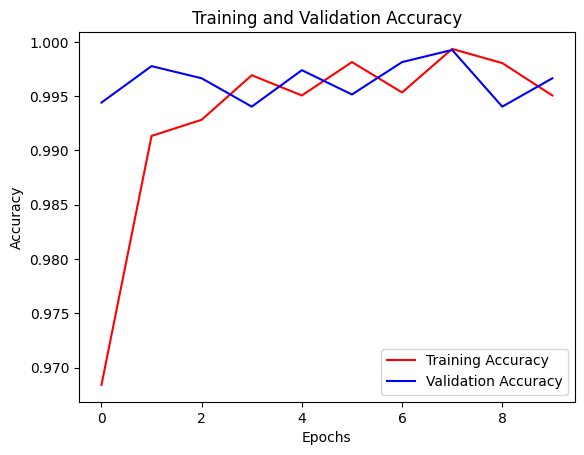

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show

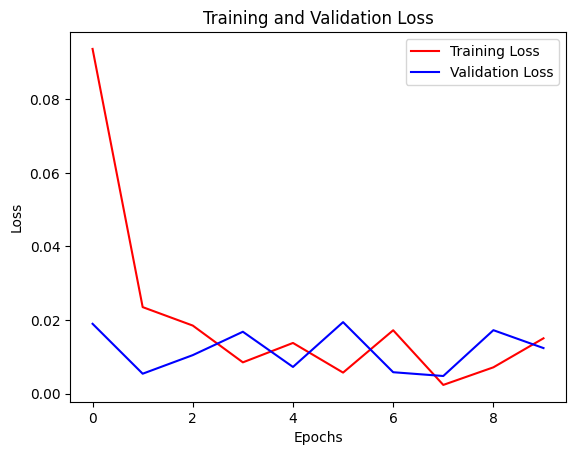

In [ ]:
plt.plot(history.history['loss'], color = 'red', label = 'Training Loss')
plt.plot(history.history['val_loss'], color = 'blue', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(
    rescale = 1./255
)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary'
)

Found 2663 images belonging to 2 classes.


In [ ]:
#Predicting the test data
predictions = model.predict(test_data)

84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[1338  554]
 [ 563  208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.71      0.71      1892
           1       0.27      0.27      0.27       771

    accuracy                           0.58      2663
   macro avg       0.49      0.49      0.49      2663
weighted avg       0.58      0.58      0.58      2663



The model is performing well on training data but not so well on test data. Hence there is overfitting which can be resolved by applying BatchNormalization and Dropout techniques


In [ ]:
#Create CNN model

model = Sequential()

model.add(Conv2D(32,(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64,(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128,(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'binary_crossentropy', #Binary classification
    metrics = ['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs = 10,
    callbacks = [checkpoint],
    validation_data = validation_data
)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9177 - loss: 2.5410
Epoch 1: val_accuracy did not improve from 0.99925
336/336 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - accuracy: 0.9488 - loss: 1.9966 - val_accuracy: 0.9657 - val_loss: 0.5792
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9795 - loss: 0.7502
Epoch 2: val_accuracy did not improve from 0.99925
336/336 ━━━━━━━━━━━━━━━━━━━━ 34s 102ms/step - accuracy: 0.9811 - loss: 0.6389 - val_accuracy: 0.8714 - val_loss: 4.4936
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9877 - loss: 0.3292
Epoch 3: val_accuracy did not improve from 0.99925
336/336 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.9876 - loss: 0.3593 - val_accuracy: 0.9161 - val_loss: 4.3735
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9901 - loss: 0.1884
Epoch 4: val_accuracy did not improve from 0.99925
336/336 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9911 - loss: 0.2015 - val_acc

In [ ]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary'
)

Found 2663 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[1333  559]
 [ 553  218]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.71      1892
           1       0.28      0.28      0.28       771

    accuracy                           0.58      2663
   macro avg       0.49      0.49      0.49      2663
weighted avg       0.58      0.58      0.58      2663



In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

resnet_model = Sequential()
pretrained_model= tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(256,256,3),
    pooling = 'max',
    classes = 2,
    weights = 'imagenet'
)

for layer in pretrained_model.layers:
  layer.trainable = False

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(1, activation='sigmoid'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
from keras.optimizers import Adam
resnet_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'binary_crossentropy', #Binary classification
    metrics = ['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

pretrained_path = "/content/drive/MyDrive/pretrained_face_model_checkpoint.keras"

CustomCheckpoint = ModelCheckpoint(
    filepath = pretrained_path,
    monitor = 'val_accuracy', #It will only save if hte 'validation accuracy' improves
    mode = 'max',
    save_best_only = True, #Overwrites the file only when it finds a better version
    verbose = 1
)

In [ ]:
history = resnet_model.fit(
    train_data,
    epochs = 10,
    callbacks=[CustomCheckpoint],
    validation_data = validation_data
)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8398 - loss: 0.7712
Epoch 1: val_accuracy improved from None to 0.92655, saving model to /content/drive/MyDrive/pretrained_face_model_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pretrained_face_model_checkpoint.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 85s 206ms/step - accuracy: 0.9085 - loss: 0.3256 - val_accuracy: 0.9265 - val_loss: 0.1671
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9455 - loss: 0.1304
Epoch 2: val_accuracy did not improve from 0.92655
336/336 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.9559 - loss: 0.1107 - val_accuracy: 0.9165 - val_loss: 0.2327
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9696 - loss: 0.0799
Epoch 3: val_accuracy improved from 0.92655 to 0.95153, saving model to /content/drive/MyDrive/pretrained_face_model_checkpoint.keras

Epoch 3: finished saving model to /content/drive/MyDrive/pretrained_face_model_che

In [ ]:
predictions = resnet_model.predict(test_data)

84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 198ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))


Confusion Matrix:
[[1369  523]
 [ 539  232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72      1892
           1       0.31      0.30      0.30       771

    accuracy                           0.60      2663
   macro avg       0.51      0.51      0.51      2663
weighted avg       0.60      0.60      0.60      2663

